# 4.3 Topics x Brands: trajectory position and composition

### Overview

Two inferential tests on the per-review LLM topic labels

**Input:** `data/stylecom_cleaned_annotated.csv` (the per-review LLM topic labels).
**Output:** none saved; the per-test summaries and the figure are shown inline.

**Pipeline:**
1. Setup and load; derive the balanced subset.
2. Test 1: mean relative position of each topic within a house's show-date trajectory,
   and the spread across topics. Effect size is Cramer's V(topic, position) against Cohen's (1988) benchmark.
3. Test 2: dependence of the topic label on the brand, as Cramer's V(brand, topic)
   against a label-permutation null (`V_excess`, the categorical analogue of the events' eta^2_excess).
4. Figures: position arc and composition null.

## 1. Setup

In [6]:
# Cell 1: Imports

import numpy as np
import pandas as pd
import scipy.stats
import matplotlib.pyplot as plt

In [ ]:
# Cell 2: Parameters

ANNOTATED_CSV = "data/stylecom_cleaned_annotated.csv"

N_TOPICS       = 10
RANDOM_STATE   = 42
N_PERMUTATIONS = 200
MIN_SIZE = 24

CRAMERS_V_SMALL = 0.10
MIN_CHAIN_LEN   = 5
N_POS_BINS      = 10

In [ ]:
# Cell 3: Load and prepare

df = pd.read_csv(ANNOTATED_CSV)

_MISSING = ["", "nan", "none"]
_auth = df["author"].astype("string").str.strip().str.lower()
df = df[~(_auth.isna() | _auth.isin(_MISSING))].reset_index(drop=True)

df["dt"] = pd.to_datetime(df["date"], format="%d-%b-%y")
df = df.rename(columns={"topic_number": "topic"})
df = df.sort_values(["designer", "dt", "review_id"]).reset_index(drop=True)
print(f"{len(df)} reviews, {df.designer.nunique()} designers, "
      f"years {df.dt.dt.year.min()}-{df.dt.dt.year.max()}")

6492 reviews, 709 designers, years 1999-2014


## 2. Test 1: do topics have a fixed place in a brand's trajectory?

In [11]:
# Cell 4: Mean relative position per topic across brand trajectories

def brand_chains(frame, min_len):
    return [g["topic"].to_numpy()
            for _, g in frame.groupby("designer", sort=False) if len(g) >= min_len]

def position_test(frame, tag):
    rows = []
    for c in brand_chains(frame, MIN_CHAIN_LEN):
        L = len(c)
        for i, e in enumerate(c):
            rows.append((e, i / (L - 1)))
    pos = pd.DataFrame(rows, columns=["topic", "rel_pos"])
    pos["bin"] = np.minimum((pos["rel_pos"] * N_POS_BINS).astype(int), N_POS_BINS - 1)
    tab = pd.crosstab(pos["topic"], pos["bin"])
    chi2, p_chi = scipy.stats.chi2_contingency(tab)[:2]
    v = np.sqrt(chi2 / (tab.values.sum() * (min(tab.shape) - 1)))
    means = pos.groupby("topic")["rel_pos"].mean()
    prange = float(means.max() - means.min())
    n_brands = len(brand_chains(frame, MIN_CHAIN_LEN))
    effect = "small+" if v > CRAMERS_V_SMALL else "negligible"
    print(f"[{tag}] brands>={MIN_CHAIN_LEN}: {n_brands}   "
          f"position {means.min():.3f}->{means.max():.3f}  range={prange:.4f}  "
          f"Cramer's V={v:.4f} (Cohen small={CRAMERS_V_SMALL})  chi2 p={p_chi:.3f} "
          f"-> {effect}")
    return dict(subset=tag, n_brands=n_brands, pos_range=round(prange, 4),
                cramers_v=round(v, 4), chi2_p=round(p_chi, 4)), means

# Restrict to the >=24-review subset (the "80% coverage" subset reported in results):
# only houses with enough reviews to trace a trajectory over time are tested.
subset = df[df.designer.isin(df.designer.value_counts()[lambda s: s >= MIN_SIZE].index)]
resA, arcs = [], {}
r, m = position_test(subset, f"subset >={MIN_SIZE}"); resA.append(r); arcs[f"subset >={MIN_SIZE}"] = m
summaryA = pd.DataFrame(resA)
summaryA

[subset >=24] brands>=5: 65   position 0.419->0.591  range=0.1716  Cramer's V=0.0950 (Cohen small=0.1)  chi2 p=0.000 -> negligible


,subset,n_brands,pos_range,cramers_v,chi2_p
0,subset >=24,65,0.1716,0.095,0.0


## 3. Test 2: does topic composition depend on the brand?

In [9]:
# Cell 5: Cramer's V(brand, topic) against the label-permutation null

def cramers_v(group, topic):
    tab = pd.crosstab(group, topic).to_numpy()
    chi2 = scipy.stats.chi2_contingency(tab, correction=False)[0]
    return np.sqrt(chi2 / (tab.sum() * (min(tab.shape) - 1)))

vc = df["designer"].value_counts()
sub = df[df["designer"].isin(vc[vc >= MIN_SIZE].index)]
g, t = sub["designer"].to_numpy(), sub["topic"].to_numpy()

v_obs = cramers_v(g, t)
rng = np.random.default_rng(RANDOM_STATE)
v_null = np.array([cramers_v(g, rng.permutation(t)) for _ in range(N_PERMUTATIONS)])
v_exc = v_obs - v_null.mean()
z = v_exc / v_null.std(ddof=1)
p_perm = (1 + (v_null >= v_obs).sum()) / (N_PERMUTATIONS + 1)
p_chi = scipy.stats.chi2_contingency(pd.crosstab(sub["designer"], sub["topic"]),
                                     correction=False)[1]

resB = dict(grouped_by="designer", min_size=MIN_SIZE, groups=sub["designer"].nunique(),
            reviews=len(sub), v_obs=round(v_obs, 4), v_null=round(v_null.mean(), 4),
            v_excess=round(v_exc, 4), z=round(z, 1), perm_p=round(p_perm, 4), chi2_p=p_chi)
print(f"{sub['designer'].nunique()} brands, {len(sub)} reviews")
print(f"Cramer's V observed = {v_obs:.4f},  null mean = {v_null.mean():.4f},  "
      f"V_excess = {v_exc:+.4f}  (z={z:.1f}, permutation p={p_perm:.4f}, chi2 p={p_chi:.1e})")
pd.DataFrame([resB])

65 brands, 1897 reviews
Cramer's V observed = 0.3398,  null mean = 0.1838,  V_excess = +0.1560  (z=27.0, permutation p=0.0050, chi2 p=6.7e-152)


## 4. Figures

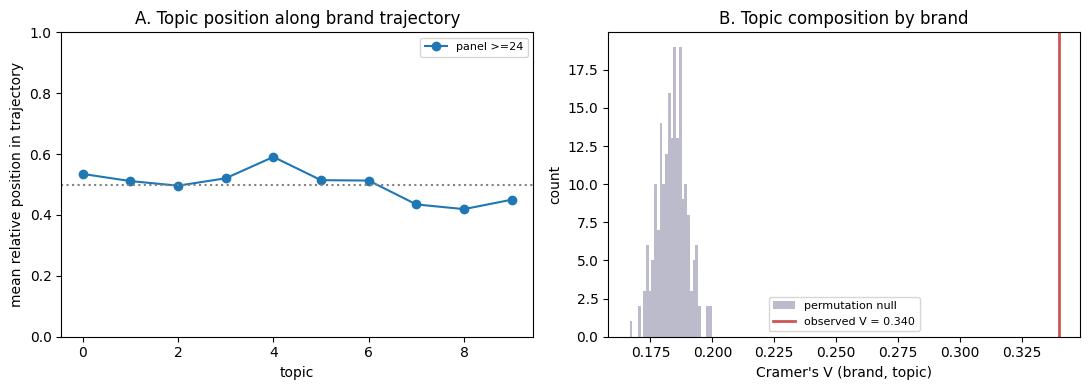

In [ ]:
# Cell 6: Position arc and composition null

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for tag, m in arcs.items():
    ax[0].plot(range(N_TOPICS), [m.get(k, np.nan) for k in range(N_TOPICS)],
               marker="o", label=tag)
ax[0].axhline(0.5, ls=":", c="grey"); ax[0].set_xlabel("topic"); ax[0].set_ylim(0, 1)
ax[0].set_ylabel("mean relative position in trajectory")
ax[0].set_title("Topic position along brand trajectory"); ax[0].legend(fontsize=8)
ax[1].hist(v_null, bins=30, color="#bbbbcc", label="permutation null")
ax[1].axvline(v_obs, color="#cc5555", lw=2, label=f"observed V = {v_obs:.3f}")
ax[1].set_xlabel("Cramer's V (brand, topic)"); ax[1].set_ylabel("count")
ax[1].set_title("Topic composition by brand"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()